In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
NUM_GPUS = torch.cuda.device_count()
print(f'Number of GPUs: {NUM_GPUS}')
for i in range(NUM_GPUS):
    print(f'  GPU {i}: {torch.cuda.get_device_name(i)}')
    print(f'  Memory: {torch.cuda.get_device_properties(i).total_memory / 1e9:.1f} GB')
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')


PyTorch: 2.10.0+cu128
CUDA available: True
Number of GPUs: 2
  GPU 0: Tesla T4
  Memory: 15.6 GB
  GPU 1: Tesla T4
  Memory: 15.6 GB


In [2]:
import os
DATA_DIR = '/kaggle/input/datasets/prateekanand172/lstgan-data'
print('Files in DATA_DIR:')
for f in sorted(os.listdir(DATA_DIR)):
    size_mb = os.path.getsize(os.path.join(DATA_DIR, f)) / 1e6
    print(f'  {f} ({size_mb:.1f} MB)')

Files in DATA_DIR:
  adj_mx_bay.pkl (1.7 MB)
  adjacency_matrix.pkl (1.7 MB)
  dataset_summary.txt (0.0 MB)
  distances.csv (0.2 MB)
  distances_bay_2017.csv (0.2 MB)
  feature_config.pkl (0.0 MB)
  graph.pkl (0.4 MB)
  graph_features.pkl (0.0 MB)
  graph_fixed.pkl (0.4 MB)
  graph_sensor_ids.txt (0.0 MB)
  pems-bay-meta.h5 (1.1 MB)
  pems-bay.h5 (135.9 MB)
  pems_bay_stations.csv (0.0 MB)
  sensor_ids.txt (0.0 MB)
  sensor_statistics.pkl (0.1 MB)
  stations_included.csv (0.0 MB)
  temporal_features_enhanced_test.pkl (0.1 MB)
  temporal_features_enhanced_train.pkl (0.5 MB)
  temporal_features_enhanced_val.pkl (0.1 MB)
  temporal_features_test.pkl (0.0 MB)
  temporal_features_train.pkl (0.1 MB)
  temporal_features_val.pkl (0.0 MB)
  time_series_test.pkl (1.9 MB)
  time_series_train.pkl (8.9 MB)
  time_series_val.pkl (1.9 MB)
  traffic_data.pkl (35.3 MB)
  traffic_stations.csv (0.0 MB)


In [3]:
import os, math, time, pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

GRAPH_FILE = os.path.join(DATA_DIR, 'adj_mx_bay.pkl')
TRAIN_FILE = '/kaggle/working/train_5min.pkl'
VAL_FILE   = '/kaggle/working/val_5min.pkl'
TEST_FILE  = '/kaggle/working/test_5min.pkl'

NUM_SENSORS=325; STEPS_PER_HOUR=12; STEPS_PER_DAY=288
WEEKLY_WINDOW=2016; DAILY_WINDOW=288; HOURLY_WINDOW=12; FORECAST_HORIZON=12
EVAL_HORIZONS=[3,6,12]
WEEKLY_IN_CHANNELS=3; WEEKLY_OUT_CHANNELS=16
DAILY_IN_CHANNELS=3; DAILY_OUT_CHANNELS=8
HOURLY_IN_CHANNELS=1
WEEKLY_STRIDE_1=14; WEEKLY_STRIDE_2=12
DAILY_STRIDE_1=4; DAILY_STRIDE_2=6
SPATIAL_EMBED_DIM=16
GLOBAL_SPATIAL_CHANNELS=16; GLOBAL_ATTN_HEADS=4; GLOBAL_ATTN_LAYERS=1
LOCAL_SPATIAL_CHANNELS=8; CHEBYSHEV_K=5
D_MODEL = WEEKLY_OUT_CHANNELS+DAILY_OUT_CHANNELS+GLOBAL_SPATIAL_CHANNELS+LOCAL_SPATIAL_CHANNELS
TIME_ONEHOT_DIM = 7+STEPS_PER_DAY
DECODER_HEADS=6; DECODER_LAYERS=1

# ─── Adaptive Graph Params (NOVELTY) ───
ADAPTIVE_EMBED_DIM = 10
ADAPTIVE_TOP_K     = 10
ADAPTIVE_INIT_ALPHA = 0.5
GRAPH_REG_WEIGHT   = 0.001

BATCH_SIZE=8; LEARNING_RATE=0.005; MAX_EPOCHS=100
EARLY_STOP_PATIENCE=10; GRAD_CLIP=5.0; WEIGHT_DECAY=1e-4
LR_PATIENCE=5; LR_FACTOR=0.5; LR_MIN=1e-6

print(f'D_MODEL={D_MODEL}, Adaptive embed_dim={ADAPTIVE_EMBED_DIM}, top_k={ADAPTIVE_TOP_K}')
print(f'Device: {DEVICE}')

D_MODEL=48, Adaptive embed_dim=10, top_k=10
Device: cuda:0


In [4]:
RAW_H5 = os.path.join(DATA_DIR, 'pems-bay.h5')
print('Loading pems-bay.h5 ...')
df = pd.read_hdf(RAW_H5)
print(f'Shape: {df.shape}')
df = df.interpolate(method='linear', axis=0, limit_direction='both')
df = df.ffill().bfill()
total = len(df)
train_end = int(total * 0.7); val_end = int(total * 0.8)
train_df=df.iloc[:train_end]; val_df=df.iloc[train_end:val_end]; test_df=df.iloc[val_end:]
print(f'Train: {train_df.shape}, Val: {val_df.shape}, Test: {test_df.shape}')
OUT_DIR = '/kaggle/working'
train_df.to_pickle(os.path.join(OUT_DIR,'train_5min.pkl'))
val_df.to_pickle(os.path.join(OUT_DIR,'val_5min.pkl'))
test_df.to_pickle(os.path.join(OUT_DIR,'test_5min.pkl'))
print('5-min Data sliced and saved!')

Loading pems-bay.h5 ...
Shape: (52116, 325)
Train: (36481, 325), Val: (5211, 325), Test: (10424, 325)
5-min Data sliced and saved!


In [5]:
class TrafficDataset(Dataset):
    def __init__(self, data_df, mode='train', mean=None, std=None):
        self.mode=mode; self.num_sensors=data_df.shape[1]
        self.mean=data_df.values.mean() if mean is None else mean
        self.std=data_df.values.std() if std is None else std
        self.speed=((data_df.values-self.mean)/(self.std+1e-8)).astype(np.float32)
        if hasattr(data_df.index,'weekday'):
            self.day_of_week=data_df.index.weekday.values
            self.time_of_day=(data_df.index.hour*12+data_df.index.minute//5).values
        else:
            T=len(data_df); self.day_of_week=np.arange(T)%7; self.time_of_day=np.arange(T)%STEPS_PER_DAY
        self.total_steps=len(self.speed); self.start_offset=WEEKLY_WINDOW
        self.valid_len=self.total_steps-self.start_offset-FORECAST_HORIZON+1
        assert self.valid_len>0
        print(f'[{mode}] {self.total_steps} steps, {self.valid_len} samples, {self.num_sensors} sensors')
    def __len__(self): return self.valid_len
    def _time_feats(self, idx, length):
        s=idx-length
        return np.stack([self.day_of_week[s:idx].astype(np.float32)/6.0, self.time_of_day[s:idx].astype(np.float32)/287.0], axis=-1)
    def __getitem__(self, idx):
        t=self.start_offset+idx; N=self.num_sensors
        sp_w=self.speed[t-WEEKLY_WINDOW:t]; tf_w=self._time_feats(t,WEEKLY_WINDOW)
        X_w=np.stack([sp_w,np.tile(tf_w[:,0:1],(1,N)),np.tile(tf_w[:,1:2],(1,N))],axis=-1)
        sp_d=self.speed[t-DAILY_WINDOW:t]; tf_d=self._time_feats(t,DAILY_WINDOW)
        X_d=np.stack([sp_d,np.tile(tf_d[:,0:1],(1,N)),np.tile(tf_d[:,1:2],(1,N))],axis=-1)
        X_h=self.speed[t-HOURLY_WINDOW:t][:,:,np.newaxis]
        t_info=np.array([self.day_of_week[t],self.time_of_day[t]],dtype=np.int64)
        Y=self.speed[t:t+FORECAST_HORIZON][:,:,np.newaxis]
        return (torch.from_numpy(X_w),torch.from_numpy(X_d),torch.from_numpy(X_h),torch.from_numpy(t_info),torch.from_numpy(Y))

def load_adjacency_matrix(path=GRAPH_FILE):
    with open(path,'rb') as f: adj=pickle.load(f,encoding='latin1')
    if isinstance(adj,(tuple,list)): adj=adj[2] if len(adj)>=3 else adj[-1]
    return adj.astype(np.float32)

def get_edge_info(adj_mx):
    rows,cols=np.nonzero(adj_mx)
    return torch.LongTensor(np.stack([rows,cols])),torch.FloatTensor(adj_mx[rows,cols])

def build_dataloaders(batch_size=BATCH_SIZE):
    print('Loading data...')
    train_df=pd.read_pickle(TRAIN_FILE); val_df=pd.read_pickle(VAL_FILE); test_df=pd.read_pickle(TEST_FILE)
    adj_mx=load_adjacency_matrix()
    print(f'Adj: {adj_mx.shape}, Train: {train_df.shape}, Val: {val_df.shape}, Test: {test_df.shape}')
    train_mean,train_std=train_df.values.mean(),train_df.values.std()
    print(f'Stats: mean={train_mean:.2f}, std={train_std:.2f}')
    train_ds=TrafficDataset(train_df,'train',train_mean,train_std)
    val_ds=TrafficDataset(val_df,'val',train_mean,train_std)
    test_ds=TrafficDataset(test_df,'test',train_mean,train_std)
    kw=dict(num_workers=4,pin_memory=True)
    train_loader=DataLoader(train_ds,batch_size=batch_size,shuffle=True,drop_last=True,**kw)
    val_loader=DataLoader(val_ds,batch_size=batch_size,shuffle=False,**kw)
    test_loader=DataLoader(test_ds,batch_size=batch_size,shuffle=False,**kw)
    edge_index,edge_weight=get_edge_info(adj_mx)
    return train_loader,val_loader,test_loader,edge_index,edge_weight,train_mean,train_std,adj_mx

print('Dataset ready.')

Dataset ready.


In [6]:
class AdaptiveGraphLearner(nn.Module):
    def __init__(self, num_nodes, embed_dim=ADAPTIVE_EMBED_DIM, alpha=ADAPTIVE_INIT_ALPHA, top_k=ADAPTIVE_TOP_K):
        super().__init__()
        self.num_nodes=num_nodes; self.embed_dim=embed_dim; self.top_k=top_k
        self.source_embed=nn.Parameter(torch.randn(num_nodes,embed_dim)*0.01)
        self.target_embed=nn.Parameter(torch.randn(num_nodes,embed_dim)*0.01)
        self.alpha_logit=nn.Parameter(torch.tensor(0.0))
    def forward(self):
        scores=torch.matmul(self.source_embed,self.target_embed.T)/(self.embed_dim**0.5)
        if self.top_k is not None and self.top_k<self.num_nodes:
            topk_vals,topk_idx=torch.topk(scores,k=self.top_k,dim=-1)
            mask=torch.full_like(scores,float('-inf'))
            mask.scatter_(-1,topk_idx,topk_vals)
            scores=mask
        adj=F.softmax(scores,dim=-1)
        eye=torch.eye(self.num_nodes,device=adj.device)
        adj=adj*(1-eye)
        row_sum=adj.sum(dim=-1,keepdim=True)
        return adj/(row_sum+1e-8)
    def get_alpha(self): return torch.sigmoid(self.alpha_logit)

def compute_scaled_laplacian(adj_tensor):
    N=adj_tensor.shape[0]; device=adj_tensor.device
    D=adj_tensor.sum(dim=1)
    D_inv_sqrt=torch.diag(1.0/torch.sqrt(D.clamp(min=1e-8)))
    I=torch.eye(N,device=device)
    L=I-D_inv_sqrt@adj_tensor@D_inv_sqrt
    eigvals=torch.linalg.eigvalsh(L)
    lambda_max=eigvals[-1].detach()
    return 2.0*L/(lambda_max+1e-8)-I

# Quick test
_gl=AdaptiveGraphLearner(10,embed_dim=4,top_k=5)
_a=_gl(); print(f'Test: shape={_a.shape}, row_sum={_a.sum(-1).mean():.4f}')
_a.sum().backward(); print(f'Gradients OK: {_gl.source_embed.grad is not None}')
del _gl,_a; print('AdaptiveGraphLearner ready.')

Test: shape=torch.Size([10, 10]), row_sum=1.0000
Gradients OK: True
AdaptiveGraphLearner ready.


In [7]:
class TemporalEncoder(nn.Module):
    def __init__(self, in_ch, out_ch, s1, s2):
        super().__init__()
        mid=max((in_ch+out_ch)//2,8)
        self.c1a=nn.Conv1d(in_ch,mid,3,padding=1)
        self.c1b=nn.Conv1d(mid,mid,s1,stride=s1) if s1>1 else nn.Identity()
        self.bn1=nn.BatchNorm1d(mid)
        self.c2a=nn.Conv1d(mid,out_ch,3,padding=1)
        self.c2b=nn.Conv1d(out_ch,out_ch,s2,stride=s2) if s2>1 else nn.Identity()
        self.bn2=nn.BatchNorm1d(out_ch)
    def forward(self,x):
        B,T,N,C=x.shape; x=x.permute(0,2,3,1).reshape(B*N,C,T)
        x=F.relu(self.bn1(self.c1b(F.relu(self.c1a(x))))); x=self.bn2(self.c2b(F.relu(self.c2a(x))))
        _,Co,To=x.shape; return x.reshape(B,N,Co,To).permute(0,3,1,2)

class SpatialEmbedding(nn.Module):
    def __init__(self, in_ch=HOURLY_IN_CHANNELS, out_ch=SPATIAL_EMBED_DIM):
        super().__init__()
        self.conv=nn.Conv1d(in_ch,out_ch,1); self.bn=nn.BatchNorm1d(out_ch)
    def forward(self,x):
        B,T,N,C=x.shape; x=x.reshape(B*T,N,C).permute(0,2,1)
        return self.bn(self.conv(x)).permute(0,2,1).reshape(B,T,N,-1)

class GlobalSpatialEncoder(nn.Module):
    def __init__(self, d=SPATIAL_EMBED_DIM, heads=GLOBAL_ATTN_HEADS, nl=GLOBAL_ATTN_LAYERS, out_ch=GLOBAL_SPATIAL_CHANNELS):
        super().__init__()
        self.layers=nn.ModuleList()
        for _ in range(nl):
            self.layers.append(nn.ModuleDict({'attn':nn.MultiheadAttention(d,heads,batch_first=True,dropout=0.1),'n1':nn.LayerNorm(d),'n2':nn.LayerNorm(d),'ffn':nn.Sequential(nn.Linear(d,d*4),nn.GELU(),nn.Dropout(0.1),nn.Linear(d*4,d))}))
        self.proj=nn.Linear(d,out_ch) if d!=out_ch else nn.Identity()
    def forward(self,x):
        B,T,N,C=x.shape; x=x.reshape(B*T,N,C)
        for l in self.layers:
            a,_=l['attn'](x,x,x); x=l['n1'](x+a); x=l['n2'](x+l['ffn'](x))
        return self.proj(x).reshape(B,T,N,-1)

class ManualChebConv(nn.Module):
    def __init__(self, in_ch, out_ch, K=CHEBYSHEV_K):
        super().__init__()
        self.K=K
        self.weights=nn.ParameterList([nn.Parameter(torch.empty(in_ch,out_ch)) for _ in range(K)])
        self.bias=nn.Parameter(torch.zeros(out_ch))
        for w in self.weights: nn.init.xavier_uniform_(w)
    def forward(self,x,L):
        Z0,Z1=x,L@x; out=Z0@self.weights[0]
        if self.K>1: out=out+Z1@self.weights[1]
        for k in range(2,self.K):
            Zk=2*L@Z1-Z0; out=out+Zk@self.weights[k]; Z0,Z1=Z1,Zk
        return out+self.bias

class LocalSpatialEncoder(nn.Module):
    """Modified: accepts L_override for adaptive graph."""
    def __init__(self, in_ch=SPATIAL_EMBED_DIM, out_ch=LOCAL_SPATIAL_CHANNELS, K=CHEBYSHEV_K):
        super().__init__()
        self.cheb=ManualChebConv(in_ch,out_ch,K); self.register_buffer('L_scaled',None)
    def set_graph(self, adj_mx):
        A=adj_mx; D_inv=np.diag(1.0/np.sqrt(np.maximum(A.sum(1),1e-8)))
        L=np.eye(A.shape[0])-D_inv@A@D_inv; eig=np.linalg.eigvalsh(L)
        device=next(self.parameters()).device
        self.L_scaled=torch.FloatTensor(2*L/(eig[-1]+1e-8)-np.eye(A.shape[0])).to(device)
    def forward(self, x, edge_index=None, edge_weight=None, L_override=None):
        B,T,N,C=x.shape; L=L_override if L_override is not None else self.L_scaled.to(x.device)
        return self.cheb(x.reshape(B*T,N,C),L).reshape(B,T,N,-1)

class TimeEncoder(nn.Module):
    def __init__(self,d=D_MODEL,tdim=TIME_ONEHOT_DIM):
        super().__init__()
        h=d*2; self.mlp=nn.Sequential(nn.Linear(tdim,h),nn.Linear(h,h),nn.ReLU(),nn.Linear(h,d)); self.norm=nn.LayerNorm(d)
    def forward(self,ste,time_info):
        B,T,N,d=ste.shape
        dow=F.one_hot(time_info[:,0].long(),7).float(); tod=F.one_hot(time_info[:,1].long(),288).float()
        vt=self.mlp(torch.cat([dow,tod],-1))[:,None,None,:].expand_as(ste)
        return self.norm(ste+vt)

class PositionalEncoding(nn.Module):
    def __init__(self,d,maxlen=500):
        super().__init__()
        pe=torch.zeros(maxlen,d); pos=torch.arange(maxlen).unsqueeze(1).float()
        div=torch.exp(torch.arange(0,d,2).float()*(-math.log(10000.0)/d))
        pe[:,0::2]=torch.sin(pos*div); pe[:,1::2]=torch.cos(pos*div)
        self.register_buffer('pe',pe.unsqueeze(0))
    def forward(self,x): return x+self.pe[:,:x.size(1),:]

class TemporalDecoder(nn.Module):
    def __init__(self,d=D_MODEL,heads=DECODER_HEADS,nl=DECODER_LAYERS,H=FORECAST_HORIZON):
        super().__init__()
        self.H=H; self.pe=PositionalEncoding(d)
        self.enc_layers=nn.ModuleList(); self.dec_layers=nn.ModuleList()
        for _ in range(nl):
            self.enc_layers.append(nn.ModuleDict({'attn':nn.MultiheadAttention(d,heads,batch_first=True,dropout=0.1),'n1':nn.LayerNorm(d),'n2':nn.LayerNorm(d),'ffn':nn.Sequential(nn.Linear(d,d*4),nn.GELU(),nn.Dropout(0.1),nn.Linear(d*4,d))}))
            self.dec_layers.append(nn.ModuleDict({'attn':nn.MultiheadAttention(d,heads,batch_first=True,dropout=0.1),'n1':nn.LayerNorm(d),'n2':nn.LayerNorm(d),'ffn':nn.Sequential(nn.Linear(d,d*4),nn.GELU(),nn.Dropout(0.1),nn.Linear(d*4,d))}))
        self.fq=nn.Parameter(torch.randn(1,H,d)*0.02); self.out_proj=nn.Linear(d,1)
    def forward(self,ste):
        B,T,N,d=ste.shape; x=ste.permute(0,2,1,3).reshape(B*N,T,d); x=self.pe(x)
        for l in self.enc_layers:
            a,_=l['attn'](x,x,x); x=l['n1'](x+a); x=l['n2'](x+l['ffn'](x))
        q=self.fq.expand(B*N,-1,-1)
        for l in self.dec_layers:
            a,_=l['attn'](q,x,x); q=l['n1'](q+a); q=l['n2'](q+l['ffn'](q))
        return self.out_proj(q).reshape(B,N,self.H,1).permute(0,2,1,3)

print('All 7 LSTGAN modules defined.')

All 7 LSTGAN modules defined.


In [8]:
class LSTGAN_Adaptive(nn.Module):
    def __init__(self, num_sensors=NUM_SENSORS):
        super().__init__()
        self.weekly_enc=TemporalEncoder(WEEKLY_IN_CHANNELS,WEEKLY_OUT_CHANNELS,WEEKLY_STRIDE_1,WEEKLY_STRIDE_2)
        self.daily_enc=TemporalEncoder(DAILY_IN_CHANNELS,DAILY_OUT_CHANNELS,DAILY_STRIDE_1,DAILY_STRIDE_2)
        self.sp_embed=SpatialEmbedding(HOURLY_IN_CHANNELS,SPATIAL_EMBED_DIM)
        self.global_enc=GlobalSpatialEncoder(SPATIAL_EMBED_DIM,GLOBAL_ATTN_HEADS,GLOBAL_ATTN_LAYERS,GLOBAL_SPATIAL_CHANNELS)
        self.local_enc=LocalSpatialEncoder(SPATIAL_EMBED_DIM,LOCAL_SPATIAL_CHANNELS,CHEBYSHEV_K)
        self.time_enc=TimeEncoder(D_MODEL)
        self.decoder=TemporalDecoder(D_MODEL,DECODER_HEADS,DECODER_LAYERS,FORECAST_HORIZON)
        self.graph_learner=AdaptiveGraphLearner(num_sensors,ADAPTIVE_EMBED_DIM,ADAPTIVE_INIT_ALPHA,ADAPTIVE_TOP_K)
        self.register_buffer('L_static',None)

    def set_static_graph(self, adj_mx):
        self.local_enc.set_graph(adj_mx)
        self.L_static=self.local_enc.L_scaled.clone()

    def _match_time(self,x,tgt):
        T=x.shape[1]
        if T==tgt: return x
        if T>tgt: return x[:,:tgt]
        B,T,N,C=x.shape; x=x.permute(0,3,2,1).reshape(B*C*N,1,T)
        x=F.interpolate(x,size=tgt,mode='nearest')
        return x.reshape(B,C,N,tgt).permute(0,3,2,1)

    def forward(self,X_w,X_d,X_h,t_info,edge_idx=None,edge_wt=None):
        adj_adaptive=self.graph_learner()
        L_adaptive=compute_scaled_laplacian(adj_adaptive)
        alpha=self.graph_learner.get_alpha()
        L_combined=alpha*self.L_static+(1-alpha)*L_adaptive

        Xw=self.weekly_enc(X_w); Xd=self.daily_enc(X_d)
        Xe=self.sp_embed(X_h); Xsa=self.global_enc(Xe)
        Xgcn=self.local_enc(Xe,L_override=L_combined)
        Tt=X_h.shape[1]; Xw=self._match_time(Xw,Tt); Xd=self._match_time(Xd,Tt)
        STe=torch.cat([Xw,Xd,Xsa,Xgcn],dim=-1)
        STE=self.time_enc(STe,t_info)
        return self.decoder(STE)

    def get_adaptive_adj(self):
        with torch.no_grad(): return self.graph_learner().cpu().numpy()

model=LSTGAN_Adaptive().to(DEVICE)
n_params=sum(p.numel() for p in model.parameters() if p.requires_grad)
n_gp=sum(p.numel() for p in model.graph_learner.parameters() if p.requires_grad)
print(f'LSTGAN+Adaptive: {n_params:,} params (~{n_params*4/1024/1024:.1f} MB)')
print(f'  Graph learner: {n_gp:,} params (embed_dim={ADAPTIVE_EMBED_DIM}, top_k={ADAPTIVE_TOP_K})')

LSTGAN+Adaptive: 115,929 params (~0.4 MB)
  Graph learner: 6,501 params (embed_dim=10, top_k=10)


In [9]:
train_loader,val_loader,test_loader,edge_index,edge_weight,train_mean,train_std,adj_mx=build_dataloaders(BATCH_SIZE)
m=model.module if hasattr(model,'module') else model
m.set_static_graph(adj_mx)
edge_index=edge_index.to(DEVICE); edge_weight=edge_weight.to(DEVICE)
print(f'\nTrain batches: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}')

Loading data...
Adj: (325, 325), Train: (36481, 325), Val: (5211, 325), Test: (10424, 325)
Stats: mean=62.74, std=9.44
[train] 36481 steps, 34454 samples, 325 sensors
[val] 5211 steps, 3184 samples, 325 sensors
[test] 10424 steps, 8397 samples, 325 sensors

Train batches: 4306, Val: 398, Test: 1050


In [10]:
def masked_mae(p,t,mv=0.0):
    m=(t!=mv); return torch.abs(p[m]-t[m]).mean() if m.sum()>0 else torch.tensor(0.0,device=p.device)
def masked_mape(p,t,mv=0.0):
    m=(t!=mv)&(t.abs()>1e-4); return (torch.abs(p[m]-t[m])/t[m].abs()).mean().item()*100 if m.sum()>0 else 0.0
def masked_rmse(p,t,mv=0.0):
    m=(t!=mv); return torch.sqrt(((p[m]-t[m])**2).mean()) if m.sum()>0 else torch.tensor(0.0,device=p.device)

@torch.no_grad()
def evaluate(model, loader, mean, std):
    model.eval(); maes,mapes,rmses=[],[],[]
    h_metrics={h:{'mae':[],'mape':[],'rmse':[]} for h in EVAL_HORIZONS}
    for batch in loader:
        Xw,Xd,Xh,ti,Y=[b.to(DEVICE) for b in batch]
        pred=model(Xw,Xd,Xh,ti,edge_index,edge_weight)
        pd_=pred*std+mean; yd=Y*std+mean
        maes.append(masked_mae(pd_,yd).item()); mapes.append(masked_mape(pd_,yd)); rmses.append(masked_rmse(pd_,yd).item())
        for h in EVAL_HORIZONS:
            if h<=pred.shape[1]:
                ph,yh=pd_[:,h-1:h],yd[:,h-1:h]
                h_metrics[h]['mae'].append(masked_mae(ph,yh).item())
                h_metrics[h]['mape'].append(masked_mape(ph,yh))
                h_metrics[h]['rmse'].append(masked_rmse(ph,yh).item())
    hr={h:{k:np.mean(v) for k,v in hm.items()} for h,hm in h_metrics.items()}
    return np.mean(maes),np.mean(mapes),np.mean(rmses),hr
print('Metrics ready.')

Metrics ready.


In [11]:
optimizer=torch.optim.AdamW(model.parameters(),lr=LEARNING_RATE,weight_decay=WEIGHT_DECAY)
scheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode='min',factor=LR_FACTOR,patience=LR_PATIENCE,min_lr=LR_MIN)
criterion=nn.L1Loss(); scaler=torch.amp.GradScaler('cuda')
best_val_mae=float('inf'); patience_counter=0
history={'train_loss':[],'val_mae':[],'val_mape':[],'val_rmse':[],'lr':[],'alpha':[]}
CKPT_PATH='/kaggle/working/best_lstgan_adaptive.pt'
start_epoch=1

if os.path.exists(CKPT_PATH):
    print(f'Resuming from {CKPT_PATH}')
    ckpt=torch.load(CKPT_PATH,map_location=DEVICE,weights_only=False)
    mdl=model.module if hasattr(model,'module') else model
    mdl.load_state_dict(ckpt['model'])
    if 'opt' in ckpt: optimizer.load_state_dict(ckpt['opt'])
    start_epoch=ckpt['epoch']+1; best_val_mae=ckpt['val_mae']
    print(f'Epoch {start_epoch}, Best MAE: {best_val_mae:.4f}')
else:
    print('Starting from scratch.')

print(f'\nTraining LSTGAN+AdaptiveGraph for {MAX_EPOCHS} epochs...')
print(f'Batch={BATCH_SIZE}, LR={LEARNING_RATE}, GraphReg={GRAPH_REG_WEIGHT}')

for epoch in range(start_epoch,MAX_EPOCHS+1):
    t0=time.time(); model.train(); losses=[]
    for batch in train_loader:
        Xw,Xd,Xh,ti,Y=[b.to(DEVICE) for b in batch]
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda'):
            pred=model(Xw,Xd,Xh,ti,edge_index,edge_weight)
            pred_loss=criterion(pred,Y)
            mdl=model.module if hasattr(model,'module') else model
            adj_a=mdl.graph_learner()
            graph_reg=GRAPH_REG_WEIGHT*torch.abs(adj_a).mean()
            loss=pred_loss+graph_reg
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(),GRAD_CLIP)
        scaler.step(optimizer); scaler.update()
        losses.append(loss.item())

    train_loss=np.mean(losses)
    val_mae,val_mape,val_rmse,val_h=evaluate(model,val_loader,train_mean,train_std)
    scheduler.step(val_mae)
    lr_now=optimizer.param_groups[0]['lr']
    mdl=model.module if hasattr(model,'module') else model
    alpha_val=mdl.graph_learner.get_alpha().item()
    elapsed=time.time()-t0

    history['train_loss'].append(train_loss); history['val_mae'].append(val_mae)
    history['val_mape'].append(val_mape); history['val_rmse'].append(val_rmse)
    history['lr'].append(lr_now); history['alpha'].append(alpha_val)

    marker=''
    if val_mae<best_val_mae:
        best_val_mae=val_mae; patience_counter=0
        ms=model.module if hasattr(model,'module') else model
        torch.save({'epoch':epoch,'model':ms.state_dict(),'opt':optimizer.state_dict(),'val_mae':val_mae,'mean':train_mean,'std':train_std},CKPT_PATH)
        marker=' BEST'
    else: patience_counter+=1

    print(f'Ep {epoch:3d}/{MAX_EPOCHS} | Loss {train_loss:.4f} | MAE {val_mae:.4f} | MAPE {val_mape:.2f}% | RMSE {val_rmse:.4f} | alpha={alpha_val:.3f} | LR {lr_now:.1e} | {elapsed:.1f}s{marker}')
    if epoch%10==0 or epoch==1:
        for h in EVAL_HORIZONS:
            r=val_h[h]; print(f'  H{h}: MAE={r["mae"]:.4f} MAPE={r["mape"]:.2f}% RMSE={r["rmse"]:.4f}')
    if patience_counter>=EARLY_STOP_PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}'); break

print(f'\nDone. Best Val MAE: {best_val_mae:.4f}')

Starting from scratch.

Training LSTGAN+AdaptiveGraph for 100 epochs...
Batch=8, LR=0.005, GraphReg=0.001
Ep   1/100 | Loss 0.1977 | MAE 1.7766 | MAPE 4.09% | RMSE 3.4332 | alpha=0.109 | LR 5.0e-03 | 455.9s BEST
  H3: MAE=1.5096 MAPE=3.27% RMSE=2.7793
  H6: MAE=1.8596 MAPE=4.28% RMSE=3.5254
  H12: MAE=2.1439 MAPE=5.10% RMSE=4.0761
Ep   2/100 | Loss 0.1750 | MAE 1.7668 | MAPE 4.43% | RMSE 3.4662 | alpha=0.098 | LR 5.0e-03 | 455.7s BEST
Ep   3/100 | Loss 0.1708 | MAE 1.6969 | MAPE 3.99% | RMSE 3.3514 | alpha=0.096 | LR 5.0e-03 | 453.5s BEST
Ep   4/100 | Loss 0.1681 | MAE 1.6792 | MAPE 3.92% | RMSE 3.3335 | alpha=0.098 | LR 5.0e-03 | 454.0s BEST
Ep   5/100 | Loss 0.1661 | MAE 1.7054 | MAPE 3.93% | RMSE 3.3675 | alpha=0.082 | LR 5.0e-03 | 453.0s
Ep   6/100 | Loss 0.1649 | MAE 1.6638 | MAPE 3.78% | RMSE 3.3090 | alpha=0.087 | LR 5.0e-03 | 454.2s BEST
Ep   7/100 | Loss 0.1639 | MAE 1.6362 | MAPE 3.77% | RMSE 3.2807 | alpha=0.088 | LR 5.0e-03 | 454.0s BEST
Ep   8/100 | Loss 0.1632 | MAE 1.638

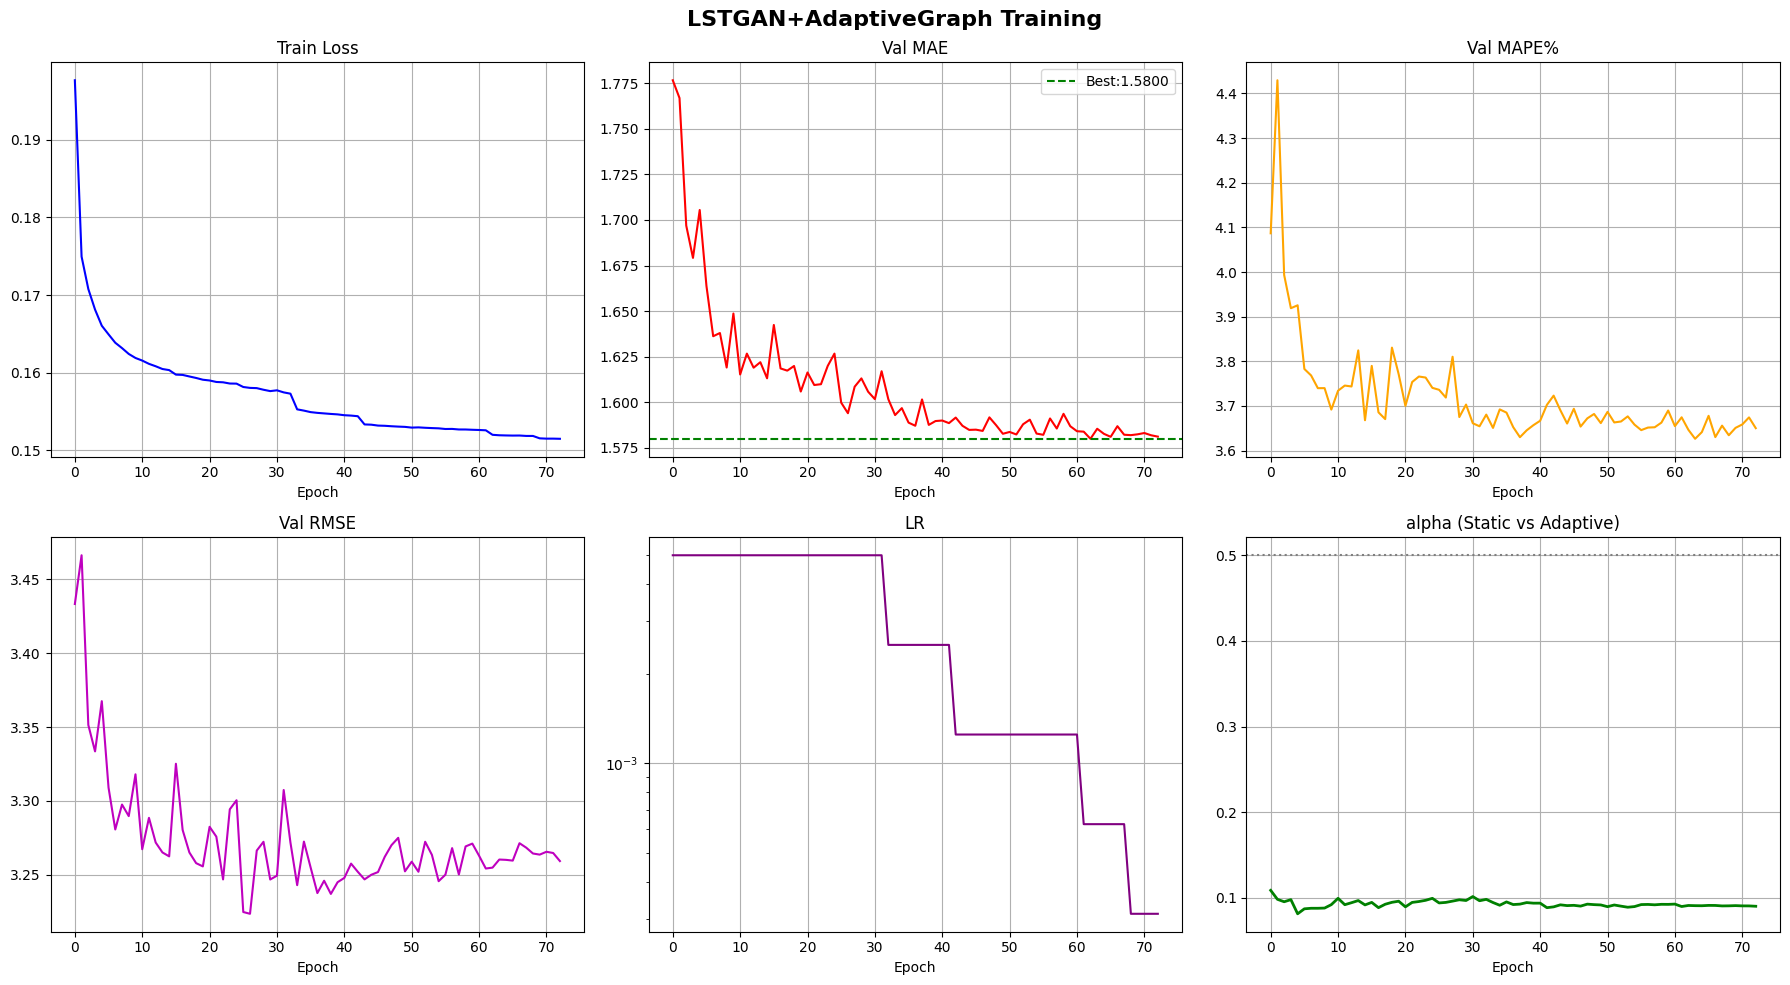

In [12]:
import matplotlib.pyplot as plt
fig,axes=plt.subplots(2,3,figsize=(18,10))
fig.suptitle('LSTGAN+AdaptiveGraph Training',fontsize=16,fontweight='bold')
axes[0,0].plot(history['train_loss'],'b-'); axes[0,0].set_title('Train Loss'); axes[0,0].grid(True)
axes[0,1].plot(history['val_mae'],'r-'); axes[0,1].axhline(best_val_mae,color='g',ls='--',label=f'Best:{best_val_mae:.4f}')
axes[0,1].set_title('Val MAE'); axes[0,1].legend(); axes[0,1].grid(True)
axes[0,2].plot(history['val_mape'],'orange'); axes[0,2].set_title('Val MAPE%'); axes[0,2].grid(True)
axes[1,0].plot(history['val_rmse'],'m-'); axes[1,0].set_title('Val RMSE'); axes[1,0].grid(True)
axes[1,1].plot(history['lr'],'purple'); axes[1,1].set_title('LR'); axes[1,1].set_yscale('log'); axes[1,1].grid(True)
axes[1,2].plot(history['alpha'],'green',lw=2); axes[1,2].set_title('alpha (Static vs Adaptive)'); axes[1,2].axhline(0.5,color='gray',ls=':'); axes[1,2].grid(True)
for ax in axes.flat: ax.set_xlabel('Epoch')
plt.tight_layout(); plt.savefig('/kaggle/working/training_curves_adaptive.png',dpi=150); plt.show()

In [13]:
ckpt=torch.load(CKPT_PATH,map_location=DEVICE,weights_only=False)
mdl=model.module if hasattr(model,'module') else model
mdl.load_state_dict(ckpt['model'])
print(f'Loaded best from epoch {ckpt["epoch"]} (MAE:{ckpt["val_mae"]:.4f})')
test_mae,test_mape,test_rmse,test_h=evaluate(model,test_loader,train_mean,train_std)

print('  LSTGAN + Adaptive Graph — TEST RESULTS')

print(f'  Overall: MAE={test_mae:.4f} | MAPE={test_mape:.2f}% | RMSE={test_rmse:.4f}')
print(f'  alpha={mdl.graph_learner.get_alpha().item():.3f}')

paper={3:{'mae':1.33,'mape':2.79,'rmse':2.80},6:{'mae':1.62,'mape':3.66,'rmse':3.63},12:{'mae':1.84,'mape':4.35,'rmse':4.18}}
for h in EVAL_HORIZONS:
    r=test_h[h]; p=paper[h]
    print(f'  H{h}({h*5}min): MAE={r["mae"]:.4f}(paper:{p["mae"]:.2f}) MAPE={r["mape"]:.2f}%(paper:{p["mape"]:.2f}%) RMSE={r["rmse"]:.4f}(paper:{p["rmse"]:.2f})')


Loaded best from epoch 63 (MAE:1.5800)
  LSTGAN + Adaptive Graph — TEST RESULTS
  Overall: MAE=1.5164 | MAPE=3.44% | RMSE=3.1085
  alpha=0.091
  H3(15min): MAE=1.3086(paper:1.33) MAPE=2.75%(paper:2.79%) RMSE=2.5179(paper:2.80)
  H6(30min): MAE=1.5867(paper:1.62) MAPE=3.63%(paper:3.66%) RMSE=3.1936(paper:3.63)
  H12(60min): MAE=1.7975(paper:1.84) MAPE=4.29%(paper:4.35%) RMSE=3.6318(paper:4.18)


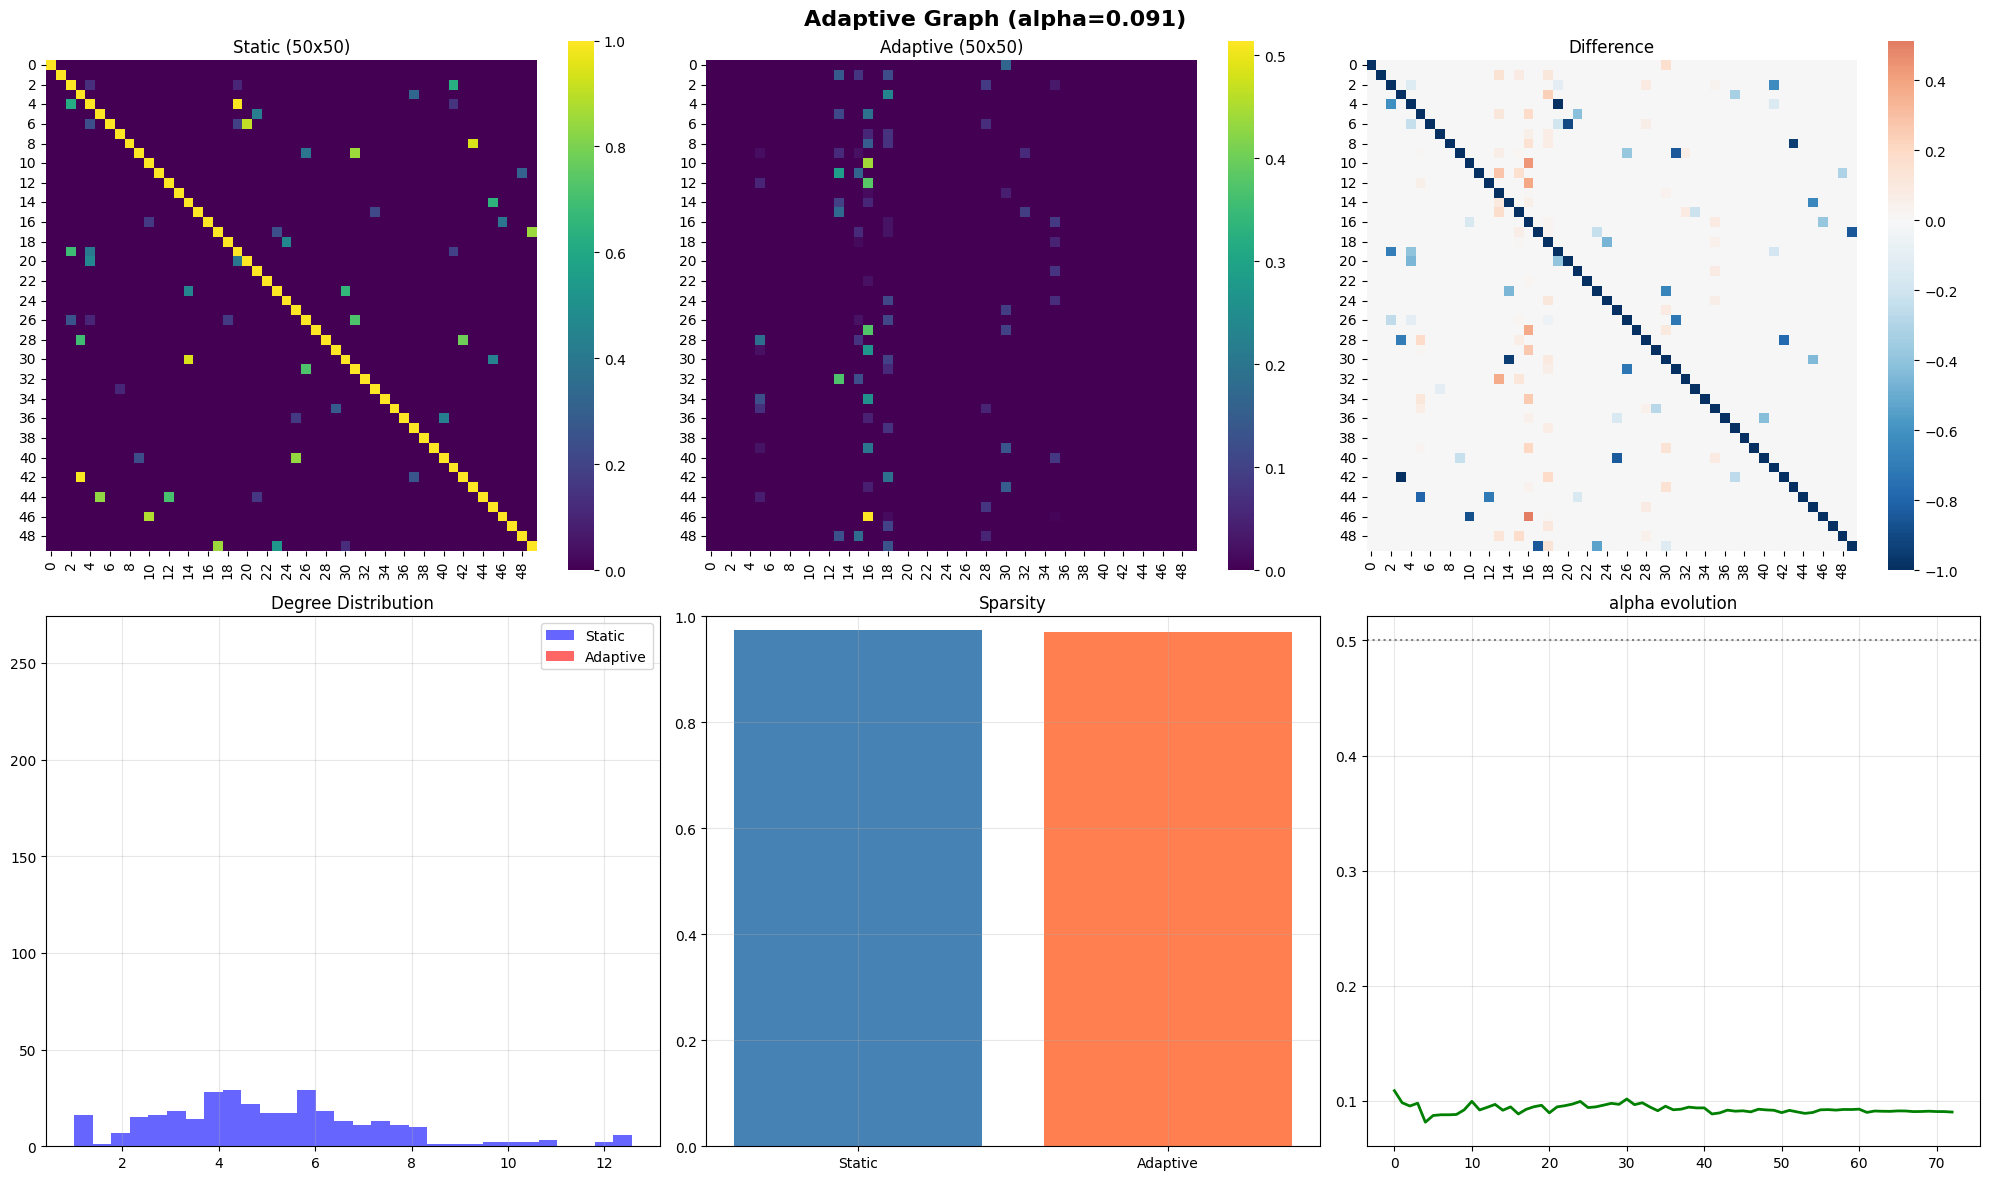

Static: deg=5.09, sparse=0.9745
Adaptive: deg=1.00, sparse=0.9703


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
mdl=model.module if hasattr(model,'module') else model
adj_adaptive=mdl.get_adaptive_adj(); adj_static=adj_mx.copy()
alpha_val=mdl.graph_learner.get_alpha().item()
fig,axes=plt.subplots(2,3,figsize=(20,12))
fig.suptitle(f'Adaptive Graph (alpha={alpha_val:.3f})',fontsize=16,fontweight='bold')
Z=50
sns.heatmap(adj_static[:Z,:Z],ax=axes[0,0],cmap='viridis',square=True); axes[0,0].set_title('Static (50x50)')
sns.heatmap(adj_adaptive[:Z,:Z],ax=axes[0,1],cmap='viridis',square=True); axes[0,1].set_title('Adaptive (50x50)')
sns.heatmap(adj_adaptive[:Z,:Z]-adj_static[:Z,:Z],ax=axes[0,2],cmap='RdBu_r',center=0,square=True); axes[0,2].set_title('Difference')
deg_s=adj_static.sum(1); deg_a=adj_adaptive.sum(1)
axes[1,0].hist(deg_s,bins=30,alpha=0.6,label='Static',color='blue')
axes[1,0].hist(deg_a,bins=30,alpha=0.6,label='Adaptive',color='red')
axes[1,0].set_title('Degree Distribution'); axes[1,0].legend(); axes[1,0].grid(True,alpha=0.3)
sp_s=(adj_static<0.01).mean(); sp_a=(adj_adaptive<0.01).mean()
axes[1,1].bar(['Static','Adaptive'],[sp_s,sp_a],color=['steelblue','coral'])
axes[1,1].set_title('Sparsity'); axes[1,1].set_ylim(0,1); axes[1,1].grid(True,alpha=0.3)
if history['alpha']:
    axes[1,2].plot(history['alpha'],'g-',lw=2); axes[1,2].set_title('alpha evolution')
    axes[1,2].axhline(0.5,color='gray',ls=':'); axes[1,2].grid(True,alpha=0.3)
plt.tight_layout(); plt.savefig('/kaggle/working/adaptive_graph_analysis.png',dpi=150); plt.show()
print(f'Static: deg={deg_s.mean():.2f}, sparse={sp_s:.4f}')
print(f'Adaptive: deg={deg_a.mean():.2f}, sparse={sp_a:.4f}')

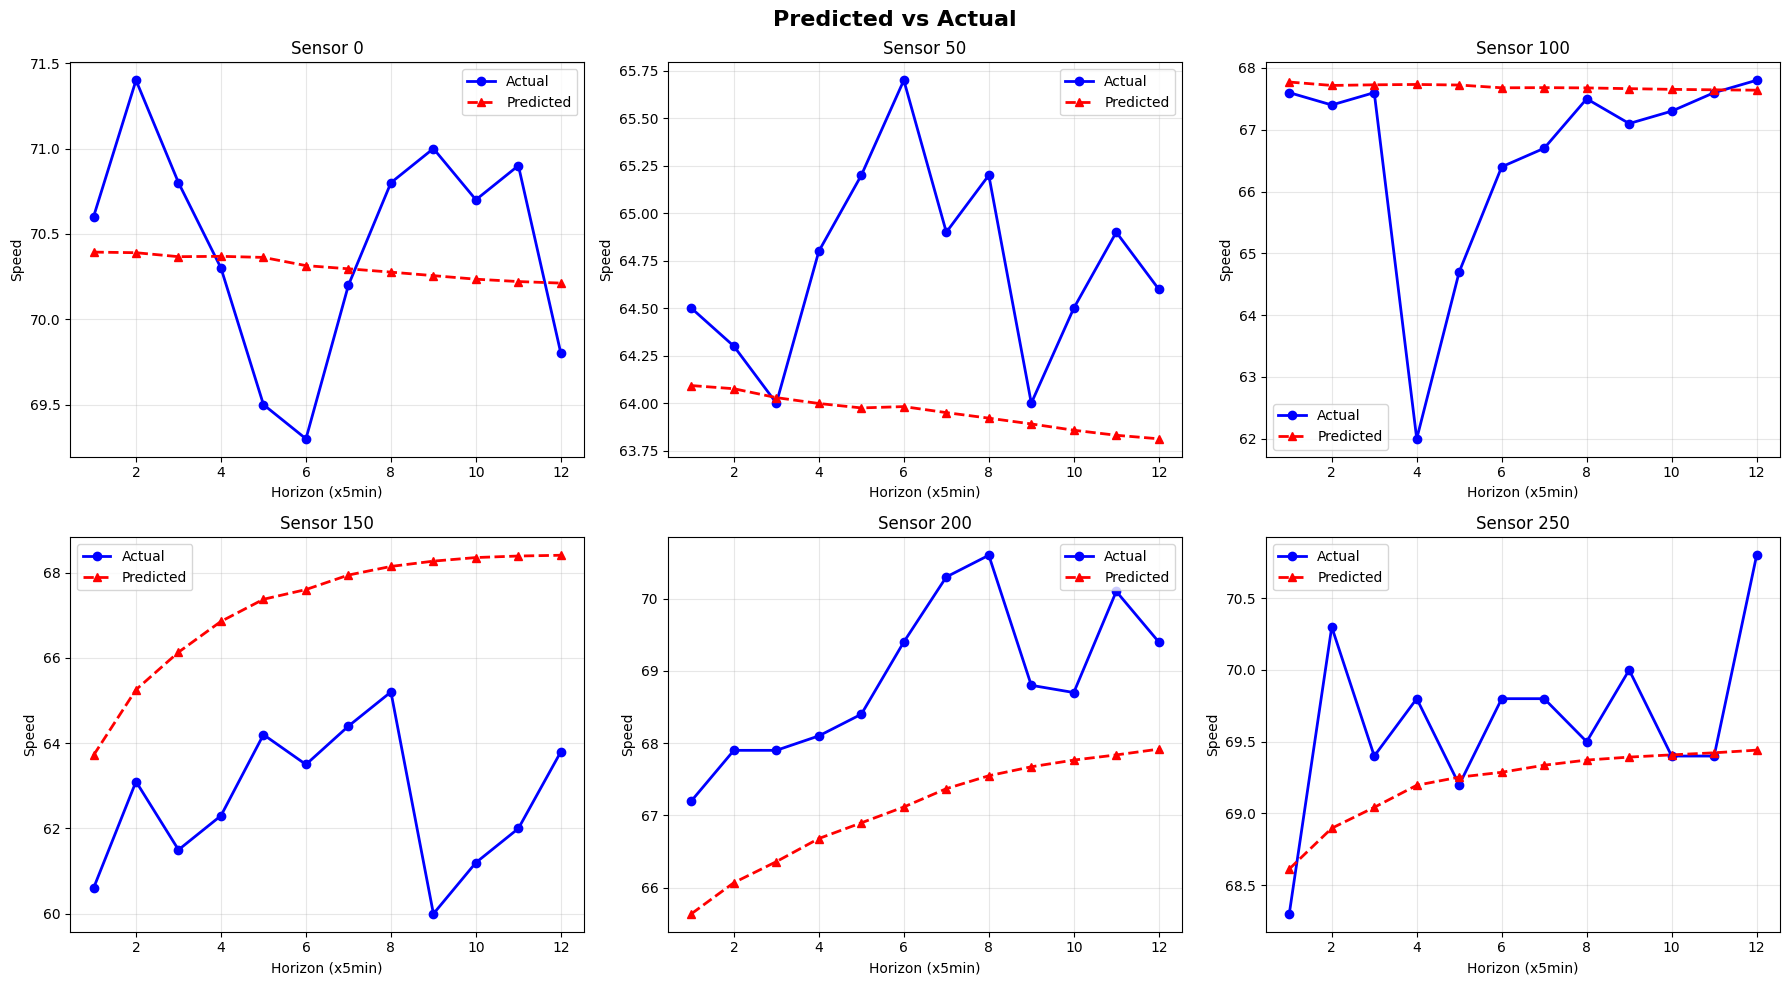

Done!


In [15]:
model.eval()
batch=next(iter(test_loader))
Xw,Xd,Xh,ti,Y=[b.to(DEVICE) for b in batch]
with torch.no_grad(): pred=model(Xw,Xd,Xh,ti,edge_index,edge_weight)
pred_np=(pred.cpu().numpy()*train_std+train_mean)
true_np=(Y.cpu().numpy()*train_std+train_mean)
fig,axes=plt.subplots(2,3,figsize=(18,10))
fig.suptitle('Predicted vs Actual',fontsize=16,fontweight='bold')
sensors=[0,50,100,150,200,250]
for i,(ax,s) in enumerate(zip(axes.flat,sensors)):
    ax.plot(range(1,FORECAST_HORIZON+1),true_np[0,:,s,0],'bo-',label='Actual',lw=2)
    ax.plot(range(1,FORECAST_HORIZON+1),pred_np[0,:,s,0],'r^--',label='Predicted',lw=2)
    ax.set_title(f'Sensor {s}'); ax.set_xlabel('Horizon (x5min)'); ax.set_ylabel('Speed')
    ax.legend(); ax.grid(True,alpha=0.3)
plt.tight_layout(); plt.savefig('/kaggle/working/predictions_adaptive.png',dpi=150); plt.show()
print('Done!')